Titanic Dashboard

Head
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S

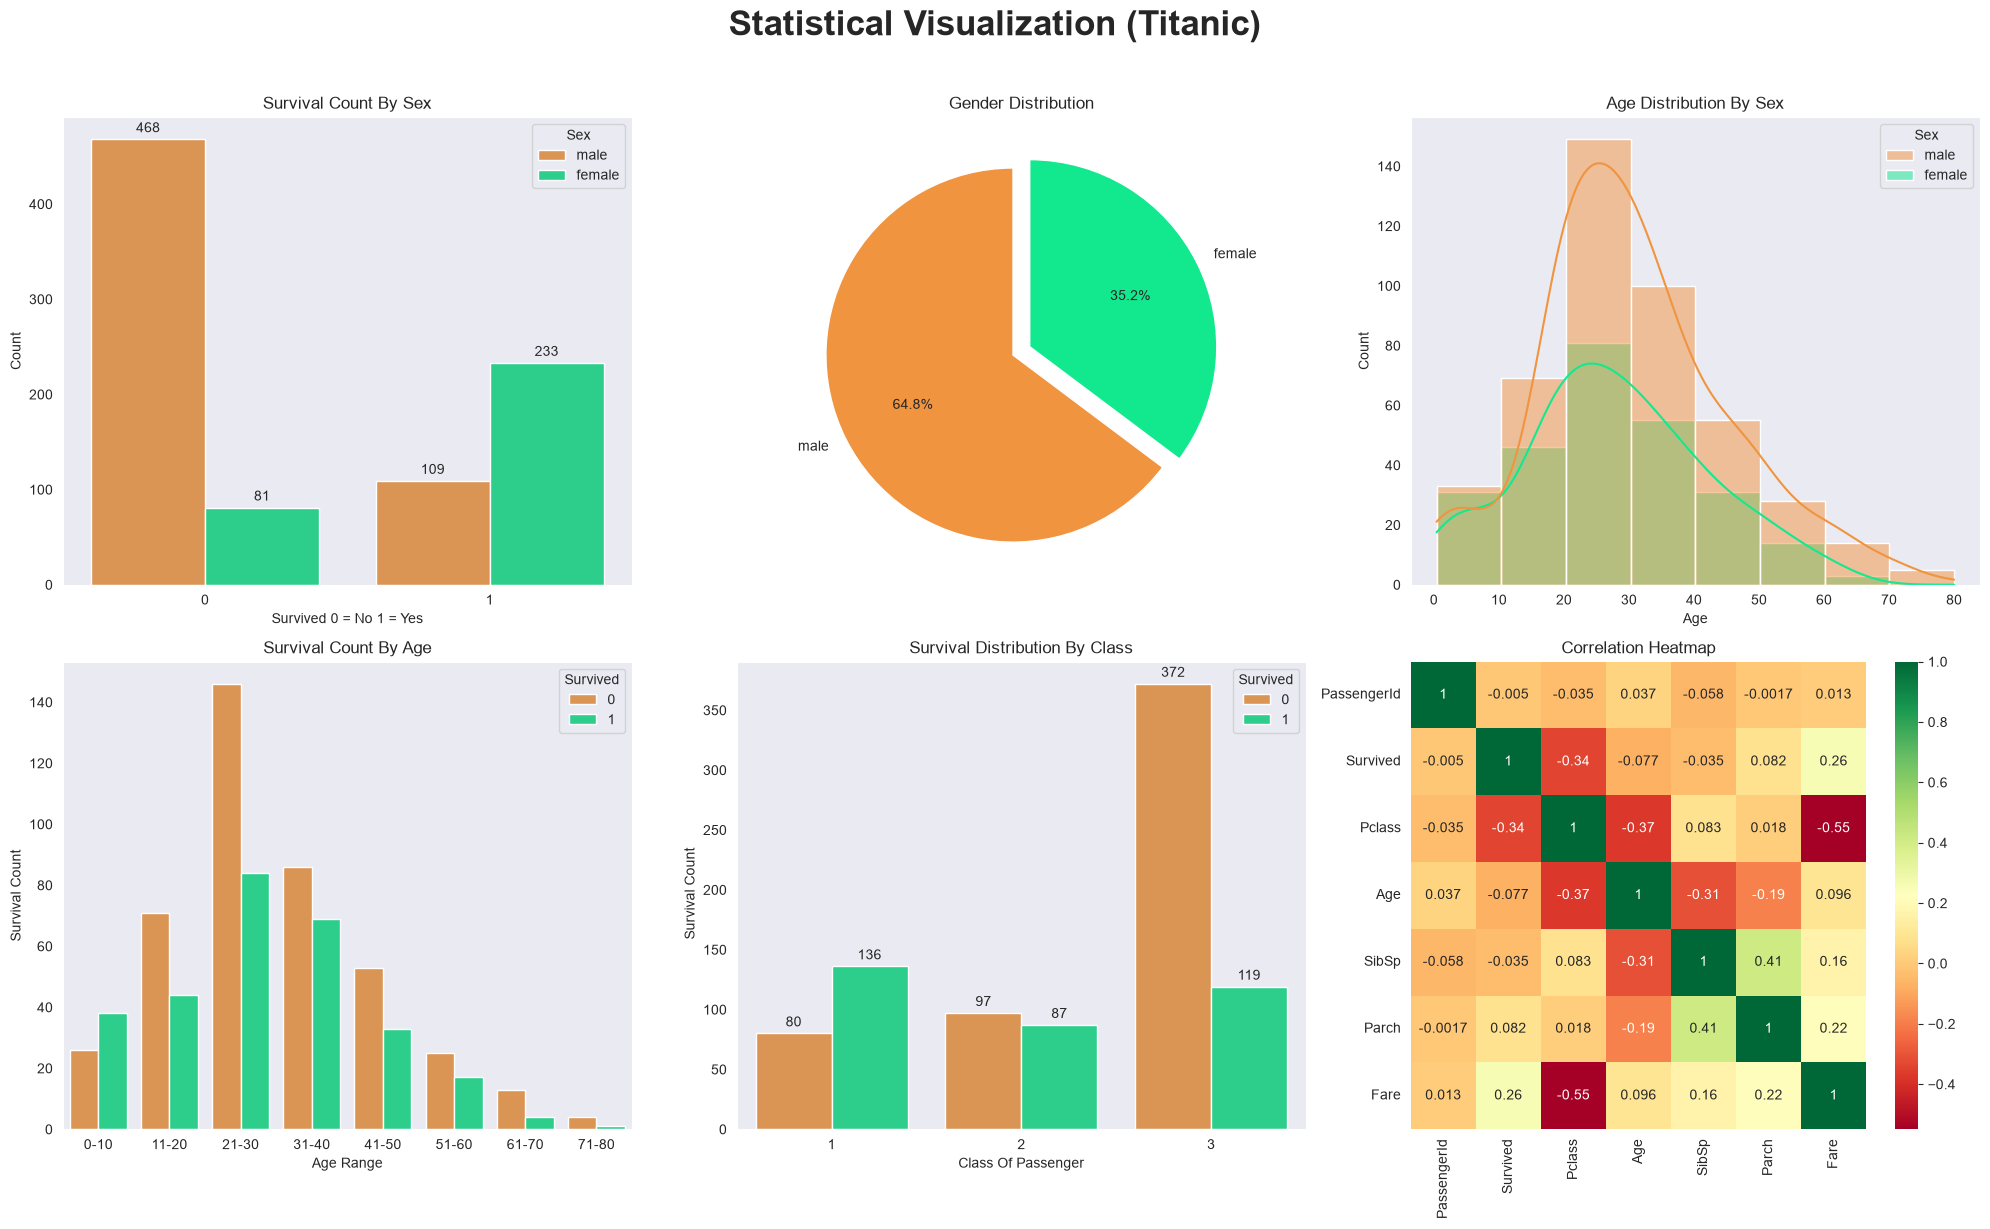

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#DATASET LOADING
train = pd.read_csv("train.csv")

#HEAD
print("Head")
print(train.head())

#SHAPE
print("Shape")
print(train.shape)

#INFO
print(train.info())

#DESCRIPTION
print(train.isnull().sum())

gender_color = {
    "male" : "#F0943F",
    "female" : "#12E98F"
}

survival_color = {
     0 : "#F0943F",
     1 : "#12E98F"
}

sns.set_style("dark")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "Statistical Visualization (Titanic)",
    fontsize=25,
    fontweight="bold", 
    y = 1.02
)


#SURVIVED
ax= sns.countplot(
    data = train,
    x = 'Survived',
    hue = 'Sex',
    palette = gender_color,
    ax = axes[0, 0]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

axes[0, 0].set_title("Survival Count By Sex")
axes[0, 0].set_xlabel("Survived 0 = No 1 = Yes")
axes[0, 0].set_ylabel("Count")

#PIE CHARTS
gender = train["Sex"].value_counts()
explode = (0.05, 0.05)

axes[0, 1].pie(
    gender,
    labels = gender.index,
    autopct = "%1.1f%%",
    explode = (0.05, 0.05),
    colors = [gender_color[s] for s in gender.index],
    startangle=90
)

axes[0, 1].set_title("Gender Distribution")

#HISTOGRAM
sns.histplot(
    data = train,
    x = "Age",
    bins = 8,
    hue = "Sex",
    kde = True,
    palette=gender_color,
    ax = axes[0, 2]
)

axes[0, 2].set_title("Age Distribution By Sex")


#COUNTPLOT
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80"]

train["AgeRange"] = pd.cut(
    train["Age"],
    bins=bins,
    labels=labels
)


sns.countplot(
    data = train,
    x = "AgeRange",
    hue= "Survived",
    palette = survival_color,
    ax = axes[1, 0]
)

axes[1, 0].set_title("Survival Count By Age")
axes[1, 0].set_xlabel("Age Range")
axes[1, 0].set_ylabel("Survival Count")


#COUNTPLOT
ax= sns.countplot(
    data = train,
    x = 'Pclass',
    hue = 'Survived',
    palette = survival_color,
    ax = axes[1, 1]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

axes[1, 1].set_title("Survival Distribution By Class")
axes[1, 1].set_xlabel("Class Of Passenger")
axes[1, 1].set_ylabel(" Survival Count")



#CORRELATION HEATMAP
numeric_data = train.select_dtypes(include="number")

correlation = numeric_data.corr()

sns.heatmap(
    data=correlation,
    annot=True,
    cmap="RdYlGn",
    ax=axes[1, 2]
)

axes[1, 2].set_title("Correlation Heatmap")


plt.tight_layout()
plt.show()